# Phase 1 — coverage & baseline-residual diagnostics
**2026-07-23**

Two diagnostics that decide whether Phase 2 (a Cacelli-baselined Δ-learning AniSOAP correction)
can work, and how it must be designed.

Phase 0 showed that per-configuration condensed-phase energies *under-determine* the pair
interaction: the GB+Q refit fit the PBE-D3 crystal energies well (r 0.97) yet came out repulsive
at the 3.9 Å cofacial stack and anti-correlated with the ab initio dimer wells. Two questions
follow:

1. **Coverage** — do the 6,826 training crystals actually constrain the pair geometries MC visits?
2. **Baseline residual** — what function must the AniSOAP correction learn: how big is it, and
   *where does its variance live*?

**Settled before starting:** the benzene molecules are rigid templates (sorted intramolecular
distance vector constant to 3.7e-8 Å over 971 molecules), so the intramolecular energy is a true
constant and the residual below is *purely intermolecular* — legitimately learnable by a
coarse-grained ellipsoid model. There is no irreducible intramolecular floor.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import ase.io
from ase.db import connect

from asmcmc.potentials import CACELLI_POTENTIAL, calc_total_energy
from asmcmc.fitting_gbq.data import build_dataset, extract_periodic_pairs, gbq
from asmcmc.fitting_gbq.fit import predict_per_mol
from asmcmc.fitting_gbq.plots import nearest_neighbor_distance

# plots.py pins the Agg backend on import (batch reporting), which would suppress
# inline figures here -- re-select the notebook backend after that import.
%matplotlib inline

TRAIN = "../data/xyz_files/ellipsoids_with_axes_and_energies.xyz"
MCDB  = "../results/validation/100.0_6.324209e-07/herringbone/simulation.db"
CACHE = "../results/fitting/cache"
FIGDIR = "../results/validation/figures"
import os; os.makedirs(FIGDIR, exist_ok=True)

# CUT_E: energy cutoff (Cacelli metrics are flat 8->10 A).  CUT_G: geometry cutoff,
# = the AniSOAP descriptor cutoff in data/anisoap_data/benzenes/make_descriptors.py.
CUT_E, CUT_G = 10.0, 7.0
theta_cacelli = (*CACELLI_POTENTIAL.gb_args, CACELLI_POTENTIAL.Q, 0.0)   # E_intra=0 -> pure lattice energy

data = build_dataset(TRAIN, CUT_E, cache_dir=CACHE)   # cached .npz; ~40 s on first run
print(f"{data.n_frames} frames, {len(data.r_mag):,} directed pairs")

6826 frames, 215,746 directed pairs


## Verification

`calc_total_energy` filters pairs with `i < j`, which silently drops **self-image** interactions
(`i == j`). These DFT cells hold 1–2 molecules, so their entire lattice energy *is* self-images —
a 1-molecule frame yields 20 neighbour pairs of which zero survive the filter, and the function
returns exactly 0. `extract_periodic_pairs`/`predict_per_mol` include self-images and are correct
here; the check below confirms that against the 7×7×7 duped supercell, where the images become
distinct particles and `calc_total_energy` is valid. (MC is unaffected: its box is far larger than
the cutoff, so a particle never reaches its own image.)

In [2]:
e_cac = predict_per_mol(theta_cacelli, data)

# 1. small-cell energies vs the duped supercell, where calc_total_energy is valid
duped = ase.io.read("../data/xyz_files/duped_ellipsoids_with_axes.xyz", ":5")
print("predict_per_mol (1-2 mol cell)  vs  calc_total_energy (7x7x7 duped)/N:")
for i, f in enumerate(duped):
    e_dup = calc_total_energy(f, CUT_E, CACELLI_POTENTIAL) / len(f)
    print(f"  frame {i}: N={len(f):3d}  {e_cac[i]:+.9f}  {e_dup:+.9f}  "
          f"{'OK' if np.isclose(e_dup, e_cac[i], rtol=1e-7) else 'MISMATCH'}")

# 2. MC-frame path: row.data['or_vec'] reconstruction -> pairs -> energy
with connect(MCDB) as db:
    row = db.get(id=1)
f = row.toatoms(); f.arrays["or_vec"] = np.asarray(row.data["or_vec"])
pairs = extract_periodic_pairs(f, "or_vec", CUT_E)
e_pairs = 0.5 * gbq(*pairs.T, *CACELLI_POTENTIAL.gb_args, CACELLI_POTENTIAL.Q).sum() / len(f)
e_direct = calc_total_energy(f, CUT_E, CACELLI_POTENTIAL) / len(f)
print(f"\nMC frame (N={len(f)}): from pairs {e_pairs:+.9f}  calc_total_energy {e_direct:+.9f}  "
      f"{'OK' if np.isclose(e_pairs, e_direct, rtol=1e-9) else 'MISMATCH'}")

predict_per_mol (1-2 mol cell)  vs  calc_total_energy (7x7x7 duped)/N:
  frame 0: N=686  -0.153157962  -0.153157962  OK
  frame 1: N=343  -0.158860755  -0.158860755  OK
  frame 2: N=343  -0.166614137  -0.166614137  OK


  frame 3: N=686  -0.141484134  -0.141484134  OK
  frame 4: N=686  -0.143792107  -0.143792107  OK



MC frame (N=400): from pairs -0.442224766  calc_total_energy -0.442224766  OK


## Step 4 — Coverage

Pair geometry is reduced to the invariants the Gay-Berne form itself depends on,
`(r, a_i = r̂·u_i, a_j = r̂·u_j, b_ij = u_i·u_j)`, returned directly by `extract_periodic_pairs`.
Ellipsoids are uniaxial with head–tail symmetry (`u ≡ −u`) and pairs are unordered, so the
physically meaningful coordinates are `r`, `|b|`, and the *sorted* pair
`a_hi = max(|a_i|,|a_j|) ≥ a_lo`.

Reading the motif map: cofacial stacking is `a_hi ≈ 1, |b| ≈ 1`; parallel-displaced is
intermediate `a_hi` with `|b| ≈ 1`; T-shaped is `|b| ≈ 0`.

In [3]:
def reduce_coords(p):
    """(r, a_hi, a_lo, |b|) from (r_mag, a_i, a_j, b_ij), symmetry-folded."""
    r, ai, aj, b = p[:, 0], np.abs(p[:, 1]), np.abs(p[:, 2]), np.abs(p[:, 3])
    return r, np.maximum(ai, aj), np.minimum(ai, aj), b

# training pairs: filter the cutoff-10 build down to the geometry cutoff (exact, free)
tr = np.stack([data.r_mag, data.a_i, data.a_j, data.b_ij], axis=1)
r_t, ahi_t, alo_t, b_t = reduce_coords(tr[tr[:, 0] <= CUT_G])

# MC pairs: 50 frames from the converged tail of the production run
with connect(MCDB) as db:
    ids = [row.id for row in db.select()]
    tail = ids[len(ids) // 2:]
    pick = tail[:: max(1, len(tail) // 50)][:50]
    blocks = []
    for i in pick:
        row = db.get(id=i)
        fr = row.toatoms(); fr.arrays["or_vec"] = np.asarray(row.data["or_vec"])
        blocks.append(extract_periodic_pairs(fr, "or_vec", CUT_G))
r_m, ahi_m, alo_m, b_m = reduce_coords(np.concatenate(blocks))

print(f"training : {len(r_t):,} pairs, r in [{r_t.min():.2f}, {r_t.max():.2f}] A")
print(f"MC       : {len(r_m):,} pairs from {len(pick)} frames, r in [{r_m.min():.2f}, {r_m.max():.2f}] A")

r_edges, g_edges = np.linspace(2.5, CUT_G, 19), np.linspace(0.0, 1.0, 11)
Ht, _ = np.histogramdd((r_t, ahi_t, b_t), bins=(r_edges, g_edges, g_edges))
Hm, _ = np.histogramdd((r_m, ahi_m, b_m), bins=(r_edges, g_edges, g_edges))
print("\nfraction of MC pair density in poorly-sampled bins:")
for thr, lab in [(0, "zero"), (10, "<10"), (100, "<100")]:
    print(f"  {lab:>5} training counts: {100 * Hm[Ht <= thr].sum() / Hm.sum():5.2f}%")

CONTACT = 4.8   # first neighbour shell -- where the interaction is decided
cm, ct = r_m <= CONTACT, r_t <= CONTACT
Htc, _ = np.histogramdd((r_t[ct], ahi_t[ct], b_t[ct]), bins=(r_edges, g_edges, g_edges))
Hmc, _ = np.histogramdd((r_m[cm], ahi_m[cm], b_m[cm]), bins=(r_edges, g_edges, g_edges))
print(f"\ncontact shell r <= {CONTACT} A  (MC {cm.sum():,} pairs, training {ct.sum():,}):")
for thr, lab in [(0, "zero"), (10, "<10")]:
    print(f"  {lab:>5} training counts: {100 * Hmc[Htc <= thr].sum() / Hmc.sum():5.2f}%")
print(f"  MC       median |b| {np.median(b_m[cm]):.3f}, a_hi {np.median(ahi_m[cm]):.3f}")
print(f"  training median |b| {np.median(b_t[ct]):.3f}, a_hi {np.median(ahi_t[ct]):.3f}")

training : 74,924 pairs, r in [2.18, 7.00] A
MC       : 288,484 pairs from 50 frames, r in [3.81, 7.00] A

fraction of MC pair density in poorly-sampled bins:
   zero training counts: 13.37%
    <10 training counts: 23.87%
   <100 training counts: 39.81%

contact shell r <= 4.8 A  (MC 42,124 pairs, training 7,990):
   zero training counts:  1.29%
    <10 training counts:  2.49%
  MC       median |b| 0.983, a_hi 0.664
  training median |b| 1.000, a_hi 0.708


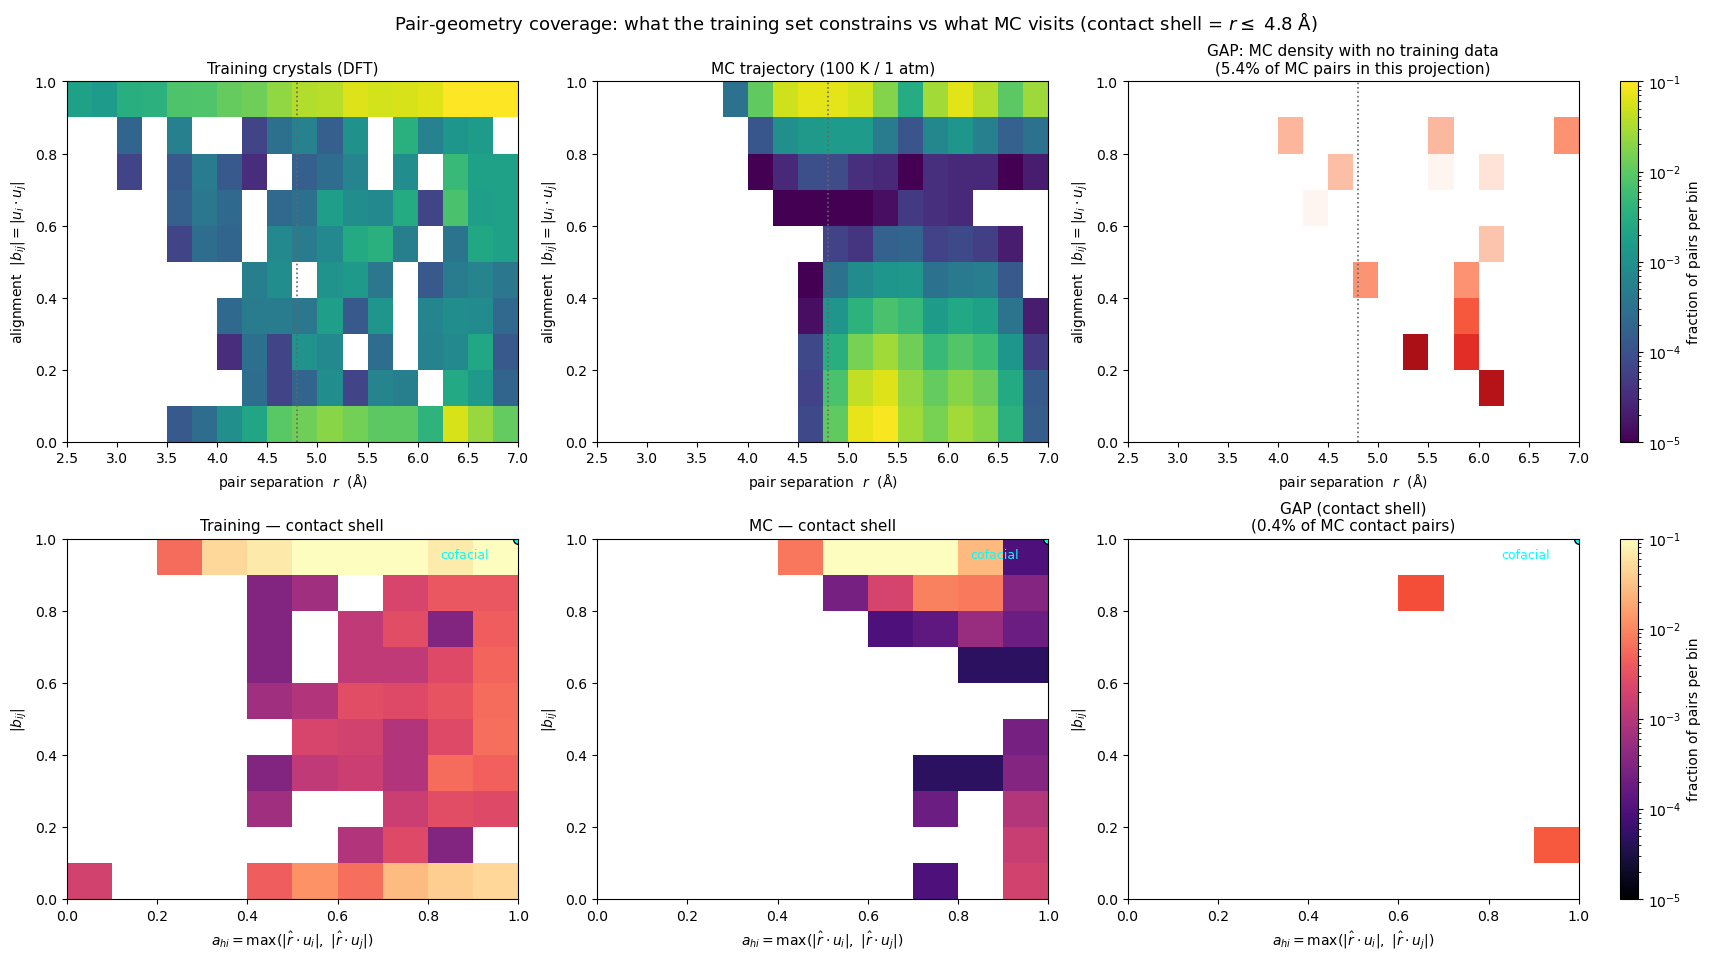

In [4]:
def density(x, y, xe, ye):
    H, _, _ = np.histogram2d(x, y, bins=[xe, ye])
    return (H / H.sum()).T

def gap_map(xm, ym, xt, yt, xe, ye):
    """MC density kept only where the training set has ZERO counts (else NaN)."""
    Hm, _, _ = np.histogram2d(xm, ym, bins=[xe, ye])
    Ht, _, _ = np.histogram2d(xt, yt, bins=[xe, ye])
    dens = Hm / Hm.sum()
    g = np.where((Ht == 0) & (Hm > 0), dens, np.nan)
    return g.T, np.nansum(g)

fig, axs = plt.subplots(2, 3, figsize=(17, 9.5), constrained_layout=True)
norm = LogNorm(vmin=1e-5, vmax=1e-1)

# --- row 0: (r, |b|) over the full descriptor range ---
for ax, (x, y, lab) in zip(axs[0], [(r_t, b_t, "Training crystals (DFT)"),
                                    (r_m, b_m, "MC trajectory (100 K / 1 atm)")]):
    pcm = ax.pcolormesh(r_edges, g_edges, density(x, y, r_edges, g_edges), cmap="viridis", norm=norm)
    ax.set_title(lab, fontsize=11)
G, gfrac = gap_map(r_m, b_m, r_t, b_t, r_edges, g_edges)
axs[0][2].pcolormesh(r_edges, g_edges, G, cmap="Reds", norm=norm)
axs[0][2].set_title(f"GAP: MC density with no training data\n({100*gfrac:.1f}% of MC pairs in this projection)",
                    fontsize=11)
for ax in axs[0]:
    ax.set_xlabel("pair separation  $r$  (Å)")
    ax.set_ylabel(r"alignment  $|b_{ij}| = |u_i\cdot u_j|$")
    ax.axvline(CONTACT, color="0.4", ls=":", lw=1.2)
fig.colorbar(pcm, ax=axs[0], label="fraction of pairs per bin", fraction=0.035, pad=0.02)

# --- row 1: contact-shell motif map ---
for ax, (x, y, lab) in zip(axs[1], [(ahi_t[ct], b_t[ct], "Training — contact shell"),
                                    (ahi_m[cm], b_m[cm], "MC — contact shell")]):
    pcm2 = ax.pcolormesh(g_edges, g_edges, density(x, y, g_edges, g_edges), cmap="magma", norm=norm)
    ax.set_title(lab, fontsize=11)
Gc, gcfrac = gap_map(ahi_m[cm], b_m[cm], ahi_t[ct], b_t[ct], g_edges, g_edges)
axs[1][2].pcolormesh(g_edges, g_edges, Gc, cmap="Reds", norm=norm)
axs[1][2].set_title(f"GAP (contact shell)\n({100*gcfrac:.1f}% of MC contact pairs)", fontsize=11)
for ax in axs[1]:
    ax.set_xlabel(r"$a_{hi} = \max(|\hat r\cdot u_i|,\ |\hat r\cdot u_j|)$")
    ax.set_ylabel(r"$|b_{ij}|$")
    ax.plot(1.0, 1.0, "o", color="cyan", ms=7, mec="k")
    ax.annotate("cofacial", (1.0, 1.0), color="cyan", xytext=(-56, -14),
                textcoords="offset points", fontsize=9)
fig.colorbar(pcm2, ax=axs[1], label="fraction of pairs per bin", fraction=0.035, pad=0.02)

fig.suptitle(f"Pair-geometry coverage: what the training set constrains vs what MC visits "
             f"(contact shell = $r \\leq$ {CONTACT} Å)", fontsize=13)
fig.savefig(f"{FIGDIR}/phase1_coverage.png", dpi=180, bbox_inches="tight")
plt.show()

## Step 5 — Baseline residual

`Δ = (E_DFT − mean) − (E_Cacelli − mean)`, both mean-referenced (the ridge intercept absorbs the
constant, and `E_intra` is a genuine constant given rigidity). **This is exactly the function the
Phase 2 AniSOAP correction has to learn.**

The regime split is the decisive cut: if Δ's variance is concentrated in the high-energy repulsive
frames, an unweighted fit will chase them and neglect the bound configurations that set the phase
behaviour — the dynamic-range trap that broke the GB+Q refit.

In [5]:
dft = data.target_per_mol
delta = (dft - dft.mean()) - (e_cac - e_cac.mean())
dft_c = dft - dft.mean()

print(f"Delta RMS {delta.std():.4f} eV/mol   (DFT spread {dft.std():.4f}, Cacelli spread {e_cac.std():.4f})")
print("percentiles [0,1,25,50,75,99,100]:", np.round(np.percentile(delta, [0,1,25,50,75,99,100]), 3))

nn = nearest_neighbor_distance(data)
vol = np.array([f.get_volume() / len(f) for f in ase.io.read(TRAIN, ":")])
print()
for name, x in [("V/molecule", vol), ("nn distance", nn), ("E_DFT", dft)]:
    print(f"  corr(|Delta|, {name:12s}) = {np.corrcoef(np.abs(delta), x)[0, 1]:+.3f}")

REGIMES = [(-np.inf, 0.0, "bound (E<0)"), (0.0, 1.0, "0-1 eV"), (1.0, np.inf, ">1 eV")]
print("\nregime split:")
masks = []
for lo, hi, lbl in REGIMES:
    m = (dft_c >= lo) & (dft_c < hi); masks.append(m)
    print(f"  {lbl:12s} n={m.sum():5d} ({100*m.mean():4.1f}%)  Delta RMS {delta[m].std():.4f}  "
          f"variance share {100*(delta[m]**2).sum()/(delta**2).sum():5.1f}%")

Delta RMS 0.4574 eV/mol   (DFT spread 0.7034, Cacelli spread 0.5398)
percentiles [0,1,25,50,75,99,100]: [-5.322 -0.384 -0.3   -0.164  0.183  1.454  3.243]



  corr(|Delta|, V/molecule  ) = +0.010
  corr(|Delta|, nn distance ) = -0.163
  corr(|Delta|, E_DFT       ) = +0.714

regime split:
  bound (E<0)  n= 4663 (68.3%)  Delta RMS 0.1255  variance share  20.9%
  0-1 eV       n= 1564 (22.9%)  Delta RMS 0.2339  variance share  21.0%
  >1 eV        n=  599 ( 8.8%)  Delta RMS 0.9107  variance share  58.0%


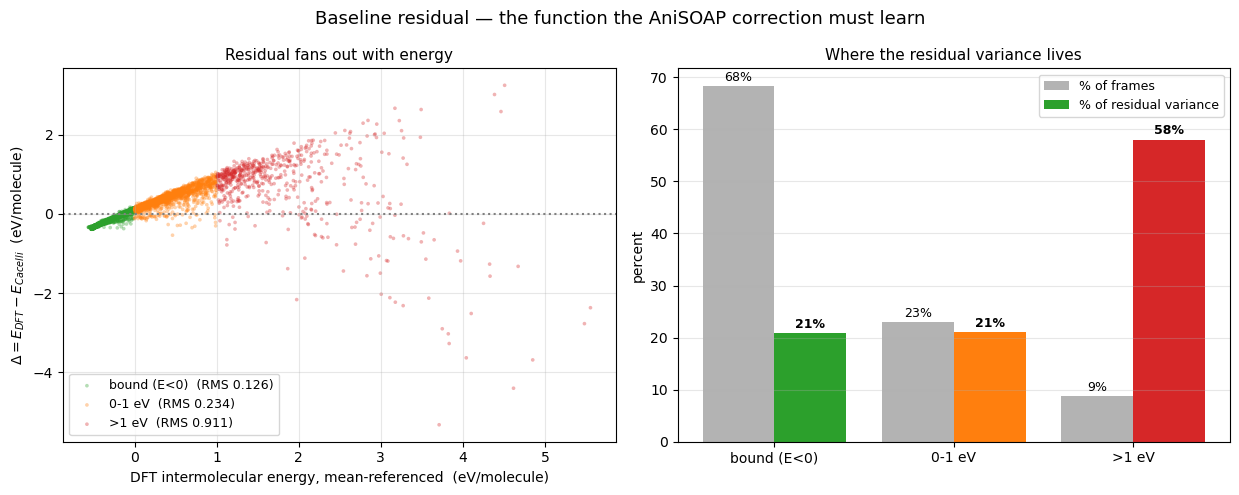

In [6]:
fig, (ax_s, ax_b) = plt.subplots(1, 2, figsize=(12.5, 5.0))
colors = ["tab:green", "tab:orange", "tab:red"]

for m, (lo, hi, lbl), c in zip(masks, REGIMES, colors):
    ax_s.scatter(dft_c[m], delta[m], s=7, alpha=0.35, edgecolors="none", color=c,
                 label=f"{lbl}  (RMS {delta[m].std():.3f})")
ax_s.axhline(0, color="0.5", ls=":")
ax_s.set_xlabel("DFT intermolecular energy, mean-referenced  (eV/molecule)")
ax_s.set_ylabel(r"$\Delta = E_{DFT} - E_{Cacelli}$  (eV/molecule)")
ax_s.set_title("Residual fans out with energy", fontsize=11)
ax_s.legend(fontsize=9, loc="lower left"); ax_s.grid(alpha=0.3)

shares = [100 * (delta[m] ** 2).sum() / (delta ** 2).sum() for m in masks]
fracs = [100 * m.mean() for m in masks]
xpos = np.arange(3)
ax_b.bar(xpos - 0.2, fracs, 0.4, label="% of frames", color="0.7")
ax_b.bar(xpos + 0.2, shares, 0.4, label="% of residual variance", color=colors)
for i, (f_, s_) in enumerate(zip(fracs, shares)):
    ax_b.text(i - 0.2, f_ + 1, f"{f_:.0f}%", ha="center", fontsize=9)
    ax_b.text(i + 0.2, s_ + 1, f"{s_:.0f}%", ha="center", fontsize=9, weight="bold")
ax_b.set_xticks(xpos); ax_b.set_xticklabels([r[2] for r in REGIMES])
ax_b.set_ylabel("percent"); ax_b.set_title("Where the residual variance lives", fontsize=11)
ax_b.legend(fontsize=9); ax_b.grid(alpha=0.3, axis="y")

fig.suptitle("Baseline residual — the function the AniSOAP correction must learn", fontsize=13)
fig.tight_layout()
fig.savefig(f"{FIGDIR}/phase1_residual.png", dpi=180, bbox_inches="tight")
plt.show()

## Findings

**Step 4 — coverage is good exactly where it matters, thin further out.**
Only **1.3 %** of MC contact-shell pair density (`r ≤ 4.8 Å`) falls in bins with zero training
counts, and the contact motif distributions broadly agree (median `|b|` 0.98 MC vs 1.00 training).
So the training crystals *do* constrain the close-contact geometries that decide binding — the
refit's stacking failure was not caused by a hole in the data there. Over the full 7 Å descriptor
range the gap is larger: **13.4 %** of MC pair density sits in unsampled bins (24 % in bins with
< 10 counts), concentrated at intermediate separations. Two caveats worth carrying into Phase 2:
the training cells hold only 1–2 molecules, so every self-image pair is *exactly* parallel
(`|b| = 1`) — orientational diversity per frame is degenerate by construction — and the training
set reaches `r = 2.18 Å` while MC never goes below 3.81 Å, i.e. the data contains a compressed
regime the sampler never visits.

**Step 5 — the residual is dominated by frames MC never visits.** Δ has an overall RMS of
**0.457 eV/molecule**, but it is *not* uniformly distributed: the 599 highest-energy frames
(8.8 % of the data) carry **58 % of the residual variance**, while the 4,663 bound frames (68 %,
and the only ones resembling a real condensed phase) have an RMS of just **0.126 eV/molecule**.
`corr(|Δ|, E_DFT) = +0.71` confirms the fan-out; density and nearest-neighbour distance explain
essentially nothing (+0.01, −0.16).

**Consequence for Phase 2.** Fitting the AniSOAP correction on unweighted energies would spend the
majority of its capacity on a repulsive tail the sampler never explores — mechanically the same
dynamic-range trap that produced a stacking-repulsive GB+Q refit. The correction should be
**weighted toward, or restricted to, the bound regime**, and **Gate A's threshold should be quoted
on the bound subset**: beat Cacelli's 0.126 eV/molecule (≈ 2.9 kcal/mol) there while still passing
the dimer-well benchmark.